In [1]:
import pandas as pd
import os
from collections import Counter
import cv2


def match_prompt_W_images(model_dir):
    initial_df = pd.DataFrame(columns=['image', 'prompt'])
    for images in os.listdir(model_dir):
        if images.endswith('.jpg') or images.endswith('.png'):
            image_path = os.path.join(model_dir, images)
            #print(image_path)
            prompt = images.split('.')[0]
            #print(prompt)
            initial_df = pd.concat([initial_df, pd.DataFrame({'image': [image_path], 'prompt': [prompt]})], ignore_index=True)
    return initial_df
            

base_df = match_prompt_W_images(model_dir='/Users/ozgeyavuz/synthbuster/dalle2')
print(base_df)


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1038d9ee0>>
Traceback (most recent call last):
  File "/Users/ozgeyavuz/synthbuster/.venv/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


                                                 image      prompt
0    /Users/ozgeyavuz/synthbuster/dalle2/r17fe8532t...  r17fe8532t
1    /Users/ozgeyavuz/synthbuster/dalle2/r0648cff8t...  r0648cff8t
2    /Users/ozgeyavuz/synthbuster/dalle2/r1c243af7t...  r1c243af7t
3    /Users/ozgeyavuz/synthbuster/dalle2/r1800ab47t...  r1800ab47t
4    /Users/ozgeyavuz/synthbuster/dalle2/r09d5cb41t...  r09d5cb41t
..                                                 ...         ...
995  /Users/ozgeyavuz/synthbuster/dalle2/r13ae7d1et...  r13ae7d1et
996  /Users/ozgeyavuz/synthbuster/dalle2/r1a711e27t...  r1a711e27t
997  /Users/ozgeyavuz/synthbuster/dalle2/r10f888c2t...  r10f888c2t
998  /Users/ozgeyavuz/synthbuster/dalle2/r11b292cbt...  r11b292cbt
999  /Users/ozgeyavuz/synthbuster/dalle2/r1a5903fct...  r1a5903fct

[1000 rows x 2 columns]


renk columnlarını set et

In [ ]:
def detect_color(image_path, top_n=3):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image at {image_path} could not be read.")
    
    # Convert from BGR to RGB (OpenCV uses BGR by default)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Reshape the image to a 2D array of pixels
    pixels = image.reshape(-1, 3)
    pixel_colors = [tuple(map(int, pixel)) for pixel in pixels]
    
    color_counts = Counter(pixel_colors)
    total_pixels = len(pixel_colors)
    
    # En baskın 3 renk ve oranları
    most_common = color_counts.most_common(top_n)
    most_common_colors = [color for color, _ in most_common]
    most_common_percentages = [round((count / total_pixels) * 100, 5) for _, count in most_common]
    
    # En az kullanılan 3 renk ve oranları
    least_common = color_counts.most_common()[-top_n:]
    least_common_colors = [color for color, _ in least_common]
    least_common_percentages = [round((count / total_pixels) * 100, 5) for _, count in least_common]
    

    
    return {
        'most_common': {
            'color': most_common_colors,
            'percentage': most_common_percentages
        },
        'least_common': {
            'color': least_common_colors,
            'percentage': least_common_percentages
        }
    }

# Test the function
color_analysis = detect_color("/Users/ozgeyavuz/synthbuster/dalle2/r0a94587ft.png")
print(f"Color analysis:")
print(f"Most common color (RGB): {color_analysis['most_common']['color']} ({color_analysis['most_common']['percentage']}%)")
print(f"Least common color (RGB): {color_analysis['least_common']['color']} ({color_analysis['least_common']['percentage']}%)")
    

In [ ]:

color_result = []
for index in range(10):  # Use len(base_df) instead of hardcoded 1000
    color_analysis = detect_color(base_df.iloc[index]['image'])
    color_analysis_df = pd.DataFrame({
        'most_common_color': [color_analysis['most_common']['color']],
        'most_common_percentage': [color_analysis['most_common']['percentage']],
        'least_common_color': [color_analysis['least_common']['color']],
        'least_common_percentage': [color_analysis['least_common']['percentage']]
    })
   # print(index)
    color_result.append(color_analysis_df)
color_analysis_df = pd.concat(color_result, ignore_index=True)
color_analysis_added_df = pd.concat([base_df, color_analysis_df], axis=1)
color_analysis_added_df.head()

brightness set et

In [ ]:
import numpy as np

def detect_brightness(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image at {image_path} could not be read.")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    pixels = image.reshape(-1, 3)
    # Parlaklık (luminance) hesapla
    brightness = 0.2126 * pixels[:, 0] + 0.7152 * pixels[:, 1] + 0.0722 * pixels[:, 2]
    avg_brightness = float(np.mean(brightness))
    max_brightness = float(np.max(brightness))
    min_brightness = float(np.min(brightness))
    return {
        'avg_brightness': avg_brightness,
        'max_brightness': max_brightness,
        'min_brightness': min_brightness
    }

In [ ]:
brightness_result = []
for index in range(10):  # Use len(base_df) instead of hardcoded 1000
    brightness = detect_brightness(base_df.iloc[index]['image'])
    brightness_df = pd.DataFrame({
        'avg_brightness': [brightness['avg_brightness']],
        'max_brightness': [brightness['max_brightness']],
        'min_brightness': [brightness['min_brightness']]
    })
    brightness_result.append(brightness_df)
brightness_analysis_df = pd.concat(brightness_result, ignore_index=True)
brightness_analysis_added_df = pd.concat([color_analysis_added_df, brightness_analysis_df], axis=1)
brightness_analysis_added_df.head()

contrast ve saturation set et
, contrast aka : std deviation of brightness
, saturation aka doygunluk


In [ ]:
def detect_contrast(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image at {image_path} could not be read.")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    pixels = image.reshape(-1, 3)
    # Y (luminance) kanalını hesapla
    Y = 0.2126 * pixels[:, 0] + 0.7152 * pixels[:, 1] + 0.0722 * pixels[:, 2]
    contrast = float(np.std(Y))
    return {'contrast': contrast}

def detect_saturation(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image at {image_path} could not be read.")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    S = hsv[:, :, 1].reshape(-1)
    avg_saturation = float(np.mean(S))
    max_saturation = float(np.max(S))
    min_saturation = float(np.min(S))
    return {
        'avg_saturation': avg_saturation,
        'max_saturation': max_saturation,
        'min_saturation': min_saturation
    }

In [ ]:
contrast_and_saturation_result = []
for index in range(10):  # Use len(base_df) instead of hardcoded 1000
    brightness = detect_contrast(base_df.iloc[index]['image'])
    saturation = detect_saturation(base_df.iloc[index]['image'])
    contrast_and_saturation_df = pd.DataFrame({
        'contrast': [brightness['contrast']],
        'avg_saturation': [saturation['avg_saturation']],
        'max_saturation': [saturation['max_saturation']],
        'min_saturation': [saturation['min_saturation']]
    })
    contrast_and_saturation_result.append(contrast_and_saturation_df)
contrast_and_saturation_df = pd.concat(contrast_and_saturation_result, ignore_index=True)
contrast_and_saturation_added_df = pd.concat([brightness_analysis_added_df, contrast_and_saturation_df], axis=1)
contrast_and_saturation_added_df.head()

simetri score assign et

In [ ]:
from skimage.metrics import structural_similarity as ssim

def compute_symmetry_score(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))  # normalize size

    # Horizontal symmetry (dikey eksende yansıma)
    flipped_h = cv2.flip(img, 1)
    score_h, _ = ssim(img, flipped_h, full=True)

    # Vertical symmetry (yatay eksende yansıma)
    flipped_v = cv2.flip(img, 0)
    score_v, _ = ssim(img, flipped_v, full=True)

    return {'horizontal_symmetry': score_h, 'vertical_symmetry': score_v}

In [ ]:
symmetry_result = []
for index in range(10):  # Use len(base_df) instead of hardcoded 1000
    symmetry_scores = compute_symmetry_score(base_df.iloc[index]['image'])
    symmetry_df = pd.DataFrame({
        'horizontal_symmetry': [symmetry_scores['horizontal_symmetry']],
        'vertical_symmetry': [symmetry_scores['vertical_symmetry']]
    })
    symmetry_result.append(symmetry_df)
symmetry_df = pd.concat(symmetry_result, ignore_index=True)
symmetry_added_df = pd.concat([contrast_and_saturation_added_df, symmetry_df], axis=1)
symmetry_added_df.head()

netlik seviyesini set et

In [ ]:
def compute_sharpness(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return laplacian_var

In [ ]:
sharpness_list = []
for index in range(10):  # Use len(base_df) instead of hardcoded 1000
    sharpness = compute_sharpness(base_df.iloc[index]['image'])
    sharpness_df = pd.DataFrame({
        'sharpness': [sharpness]
    })
    sharpness_list.append(sharpness_df)
sharpness_df = pd.concat(sharpness_list, ignore_index=True)
sharpness_added_df = pd.concat([symmetry_added_df, sharpness_df], axis=1)
sharpness_added_df.head()

görüntüdeki edge yoğunluğunu set et

In [ ]:
def compute_edge_density(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))
    edges = cv2.Canny(img, 100, 200)
    edge_pixels = np.sum(edges > 0)
    total_pixels = edges.size
    return edge_pixels / total_pixels

edge_density_list = []
for index in range(10):  # Use len(base_df) instead of hardcoded 1000
    edge_density = compute_edge_density(base_df.iloc[index]['image'])
    edge_density_df = pd.DataFrame({
        'edge_density': [edge_density]
    })
    edge_density_list.append(edge_density_df)
edge_density_df = pd.concat(edge_density_list, ignore_index=True)
edge_density_added_df = pd.concat([sharpness_added_df, edge_density_df], axis=1)
edge_density_added_df.head()

boşluk oranı set et

In [ ]:
def compute_whitespace_ratio(image_path, threshold=245):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    white_pixels = np.sum(img > threshold)
    return white_pixels / img.size
whitespace_ratio_list = []
for index in range(10):  # Use len(base_df) instead of hardcoded 1000
    whitespace_ratio = compute_whitespace_ratio(base_df.iloc[index]['image'])
    whitespace_ratio_df = pd.DataFrame({
        'whitespace_ratio': [whitespace_ratio]
    })
    whitespace_ratio_list.append(whitespace_ratio_df)
whitespace_ratio_df = pd.concat(whitespace_ratio_list, ignore_index=True)
whitespace_ratio_added_df = pd.concat([edge_density_added_df, whitespace_ratio_df], axis=1)
whitespace_ratio_added_df.head()

In [ ]:
import pandas as pd
import os
from collections import Counter
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim


def match_prompt_W_images(model_dir):
    initial_df = pd.DataFrame(columns=['image', 'prompt'])
    for images in os.listdir(model_dir):
        if images.endswith('.jpg') or images.endswith('.png'):
            image_path = os.path.join(model_dir, images)
            #print(image_path)
            prompt = images.split('.')[0]
            #print(prompt)
            initial_df = pd.concat([initial_df, pd.DataFrame({'image': [image_path], 'prompt': [prompt]})], ignore_index=True)
    return initial_df
            
def compute_whitespace_ratio(image_path, threshold=245):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    white_pixels = np.sum(img > threshold)
    return white_pixels / img.size

def compute_edge_density(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))
    edges = cv2.Canny(img, 100, 200)
    edge_pixels = np.sum(edges > 0)
    total_pixels = edges.size
    return edge_pixels / total_pixels

def compute_sharpness(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return laplacian_var

def compute_symmetry_score(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256))  # normalize size

    # Horizontal symmetry (dikey eksende yansıma)
    flipped_h = cv2.flip(img, 1)
    score_h, _ = ssim(img, flipped_h, full=True)

    # Vertical symmetry (yatay eksende yansıma)
    flipped_v = cv2.flip(img, 0)
    score_v, _ = ssim(img, flipped_v, full=True)

    return {'horizontal_symmetry': score_h, 'vertical_symmetry': score_v}

def detect_contrast(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image at {image_path} could not be read.")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    pixels = image.reshape(-1, 3)
    # Y (luminance) kanalını hesapla
    Y = 0.2126 * pixels[:, 0] + 0.7152 * pixels[:, 1] + 0.0722 * pixels[:, 2]
    contrast = float(np.std(Y))
    return {'contrast': contrast}

def detect_saturation(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image at {image_path} could not be read.")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    S = hsv[:, :, 1].reshape(-1)
    avg_saturation = float(np.mean(S))
    max_saturation = float(np.max(S))
    min_saturation = float(np.min(S))
    return {
        'avg_saturation': avg_saturation,
        'max_saturation': max_saturation,
        'min_saturation': min_saturation
    }

def detect_brightness(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image at {image_path} could not be read.")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    pixels = image.reshape(-1, 3)
    # Parlaklık (luminance) hesapla
    brightness = 0.2126 * pixels[:, 0] + 0.7152 * pixels[:, 1] + 0.0722 * pixels[:, 2]
    avg_brightness = float(np.mean(brightness))
    max_brightness = float(np.max(brightness))
    min_brightness = float(np.min(brightness))
    return {
        'avg_brightness': avg_brightness,
        'max_brightness': max_brightness,
        'min_brightness': min_brightness
    }

def detect_color(image_path, top_n=3):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image at {image_path} could not be read.")
    
    # Convert from BGR to RGB (OpenCV uses BGR by default)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Reshape the image to a 2D array of pixels
    pixels = image.reshape(-1, 3)
    pixel_colors = [tuple(map(int, pixel)) for pixel in pixels]
    
    color_counts = Counter(pixel_colors)
    total_pixels = len(pixel_colors)
    
    # En baskın 3 renk ve oranları
    most_common = color_counts.most_common(top_n)
    most_common_colors = [color for color, _ in most_common]
    most_common_percentages = [round((count / total_pixels) * 100, 5) for _, count in most_common]
    
    # En az kullanılan 3 renk ve oranları
    least_common = color_counts.most_common()[-top_n:]
    least_common_colors = [color for color, _ in least_common]
    least_common_percentages = [round((count / total_pixels) * 100, 5) for _, count in least_common]
    

    
    return {
        'most_common': {
            'color': most_common_colors,
            'percentage': most_common_percentages
        },
        'least_common': {
            'color': least_common_colors,
            'percentage': least_common_percentages
        }
    }

def estimate_datatable(base_df):  
    
    whitespace_ratio_list = []
    edge_density_list = []
    sharpness_list = []
    symmetry_result = []
    contrast_and_saturation_result = []
    brightness_result = []
    color_result = []



    for index in range(len(base_df)):  # Use len(base_df) instead of hardcoded 1000
        #whitespace
        whitespace_ratio = compute_whitespace_ratio(base_df.iloc[index]['image'])
        whitespace_ratio_df = pd.DataFrame({
            'whitespace_ratio': [whitespace_ratio]
        })
        whitespace_ratio_list.append(whitespace_ratio_df)
        #edge_density
        edge_density = compute_edge_density(base_df.iloc[index]['image'])
        edge_density_df = pd.DataFrame({
            'edge_density': [edge_density]
        })
        edge_density_list.append(edge_density_df)

        #sharpness
        sharpness = compute_sharpness(base_df.iloc[index]['image'])
        sharpness_df = pd.DataFrame({
            'sharpness': [sharpness]
        })
        sharpness_list.append(sharpness_df)

        #symmetry
        symmetry_scores = compute_symmetry_score(base_df.iloc[index]['image'])
        symmetry_df = pd.DataFrame({
            'horizontal_symmetry': [symmetry_scores['horizontal_symmetry']],
            'vertical_symmetry': [symmetry_scores['vertical_symmetry']]
        })
        symmetry_result.append(symmetry_df)

        #contrast and saturation
        brightness = detect_contrast(base_df.iloc[index]['image'])
        saturation = detect_saturation(base_df.iloc[index]['image'])
        contrast_and_saturation_df = pd.DataFrame({
            'contrast': [brightness['contrast']],
            'avg_saturation': [saturation['avg_saturation']],
            'max_saturation': [saturation['max_saturation']],
            'min_saturation': [saturation['min_saturation']]
        })
        contrast_and_saturation_result.append(contrast_and_saturation_df)

        #brightness
        brightness = detect_brightness(base_df.iloc[index]['image'])
        brightness_df = pd.DataFrame({
            'avg_brightness': [brightness['avg_brightness']],
            'max_brightness': [brightness['max_brightness']],
            'min_brightness': [brightness['min_brightness']]
        })
        brightness_result.append(brightness_df)

        #color
        color_analysis = detect_color(base_df.iloc[index]['image'])
        color_analysis_df = pd.DataFrame({
            'most_common_color': [color_analysis['most_common']['color']],
            'most_common_percentage': [color_analysis['most_common']['percentage']],
            'least_common_color': [color_analysis['least_common']['color']],
            'least_common_percentage': [color_analysis['least_common']['percentage']]
        })
        color_result.append(color_analysis_df)

    color_analysis_df = pd.concat(color_result, ignore_index=True)
    color_analysis_added_df = pd.concat([base_df, color_analysis_df], axis=1)
    #color_analysis_added_df.head()

    brightness_analysis_df = pd.concat(brightness_result, ignore_index=True)
    brightness_analysis_added_df = pd.concat([color_analysis_added_df, brightness_analysis_df], axis=1)
    #brightness_analysis_added_df.head()

    contrast_and_saturation_df = pd.concat(contrast_and_saturation_result, ignore_index=True)
    contrast_and_saturation_added_df = pd.concat([brightness_analysis_added_df, contrast_and_saturation_df], axis=1)
    #contrast_and_saturation_added_df.head()

    symmetry_df = pd.concat(symmetry_result, ignore_index=True)
    symmetry_added_df = pd.concat([contrast_and_saturation_added_df, symmetry_df], axis=1)
    #symmetry_added_df.head()

    sharpness_df = pd.concat(sharpness_list, ignore_index=True)
    sharpness_added_df = pd.concat([symmetry_added_df, sharpness_df], axis=1)
    #sharpness_added_df.head()

    edge_density_df = pd.concat(edge_density_list, ignore_index=True)
    edge_density_added_df = pd.concat([sharpness_added_df, edge_density_df], axis=1)
    #edge_density_added_df.head()    
        
    whitespace_ratio_df = pd.concat(whitespace_ratio_list, ignore_index=True)
    whitespace_ratio_added_df = pd.concat([edge_density_added_df, whitespace_ratio_df], axis=1)
    #whitespace_ratio_added_df.head()

    
    return whitespace_ratio_added_df
   



   

    

    

In [ ]:
base_df = match_prompt_W_images(model_dir='/Users/ozgeyavuz/synthbuster/dalle2')
final_df = estimate_datatable(base_df)
final_df.head()

#save base_df



In [ ]:
final_df.to_csv('/Users/ozgeyavuz/synthbuster/dalle2/base_df.csv', index=False)

In [ ]:
base_df2 = match_prompt_W_images(model_dir='/Users/ozgeyavuz/synthbuster/midjourney-v5')
final_df2 = estimate_datatable(base_df2)
final_df2.head()


In [ ]:
final_df2.to_csv('/Users/ozgeyavuz/synthbuster/midjourney-v5/base_df.csv', index=False)

In [2]:
base_df3 = match_prompt_W_images(model_dir='/Users/ozgeyavuz/synthbuster/stable-diffusion-1-4')
final_df3 = estimate_datatable(base_df3)
final_df3.head()

final_df3.to_csv('/Users/ozgeyavuz/synthbuster/stable-diffusion-1-4/base_df.csv', index=False)

NameError: name 'estimate_datatable' is not defined

In [ ]:
import pandas as pd
final_df = pd.read_csv('/Users/ozgeyavuz/synthbuster/dalle2/base_df.csv')
final_df2 = pd.read_csv('/Users/ozgeyavuz/synthbuster/midjourney-v5/base_df.csv')
final_df3 = pd.read_csv('/Users/ozgeyavuz/synthbuster/stable-diffusion-1-4/base_df.csv')
# Add model labels
final_df['model'] = 'dalle2'
final_df2['model'] = 'midjourney-v5'
final_df3['model'] = 'stable-diffusion-1-4'

# Combine all into one DataFrame
all_df = pd.concat([final_df, final_df2, final_df3], ignore_index=True)



In [ ]:
import ast

# Safely convert string representation of list/tuple to actual Python object
all_df[['most_common_color_R', 'most_common_color_G', 'most_common_color_B']] = all_df['most_common_color'].apply(lambda x: pd.Series(ast.literal_eval(x)[0]))
all_df[['least_common_color_R', 'least_common_color_G', 'least_common_color_B']] = all_df['least_common_color'].apply(lambda x: pd.Series(ast.literal_eval(x)[0]))
all_df = all_df.drop(columns=['most_common_color', 'least_common_color'])
all_df.head()
#most common percentage
all_df[['most_common_percentage_1', 'most_common_percentage_2', 'most_common_percentage_3']] = all_df['most_common_percentage'].apply(lambda x: pd.Series(ast.literal_eval(x)))
all_df[['least_common_percentage_1', 'least_common_percentage_2', 'least_common_percentage_3']] = all_df['least_common_percentage'].apply(lambda x: pd.Series(ast.literal_eval(x)))
all_df = all_df.drop(columns=['most_common_percentage', 'least_common_percentage'])     
all_df.head()

,image,prompt,avg_brightness,max_brightness,min_brightness,contrast,avg_saturation,max_saturation,min_saturation,horizontal_symmetry,...,most_common_color_B,least_common_color_R,least_common_color_G,least_common_color_B,most_common_percentage_1,most_common_percentage_2,most_common_percentage_3,least_common_percentage_1,least_common_percentage_2,least_common_percentage_3
0,/Users/ozgeyavuz/synthbuster/dalle2/r17fe8532t...,r17fe8532t,133.124648,255.0000,0.0000,71.515001,38.989592,255.0,0.0,0.307190,...,214,226,226,217,0.10223,0.09489,0.09089,0.0001,0.0001,0.0001
1,/Users/ozgeyavuz/synthbuster/dalle2/r0648cff8t...,r0648cff8t,115.525865,255.0000,3.5748,57.524662,55.867724,255.0,0.0,0.121212,...,255,168,159,156,0.02375,0.01392,0.01383,0.0001,0.0001,0.0001
2,/Users/ozgeyavuz/synthbuster/dalle2/r1c243af7t...,r1c243af7t,142.339941,255.0000,0.8504,51.571350,99.460009,255.0,0.0,0.052151,...,223,141,120,39,0.02317,0.02241,0.02203,0.0001,0.0001,0.0001
3,/Users/ozgeyavuz/synthbuster/dalle2/r1800ab47t...,r1800ab47t,94.856203,254.5748,0.0000,47.815381,92.816821,255.0,0.0,0.155678,...,10,175,152,84,0.00973,0.00896,0.00868,0.0001,0.0001,0.0001
4,/Users/ozgeyavuz/synthbuster/dalle2/r09d5cb41t...,r09d5cb41t,144.620833,244.6070,17.0458,42.049943,109.927796,255.0,0.0,0.260665,...,152,146,135,128,0.02966,0.02937,0.02861,0.0001,0.0001,0.0001


In [ ]:
# #show hist of the edge_density by showing which color is belongs to which model 
# import matplotlib.pyplot as plt
# import seaborn as sns
# for column in all_df.drop(columns=['image', 'prompt', 'model']).columns:
#     print(f"Plotting histogram for {column}")
#     ax = sns.histplot(data=all_df, x=column, hue='model', multiple='stack', kde=True)
#     plt.figure(figsize=(12, 6))
#     palette = {'dalle2': 'blue', 'midjourney-v5': 'green', 'stable-diffusion-1-4': 'red'}

#     import matplotlib.pyplot as plt
#     import seaborn as sns
#     plt.figure(figsize=(12, 6))
#     sns.boxplot(x='model', y=column, data=all_df)
#     plt.title(f'Boxplot of {column} by Model')
#     plt.show()

In [ ]:
print(all_df.groupby('model')['least_common_percentage_1'].unique())

model
dalle2                         [0.0001]
midjourney-v5           [8e-05, 0.0001]
stable-diffusion-1-4          [0.00038]
Name: least_common_percentage_1, dtype: object


In [ ]:
all_df = all_df.drop(columns=['least_common_percentage_1','least_common_percentage_2','least_common_percentage_3'])

In [ ]:
print(all_df.groupby('model')['most_common_percentage_3'].unique())

model
dalle2                  [0.09089, 0.01383, 0.02203, 0.00868, 0.02861, ...
midjourney-v5           [2.49581, 0.05096, 0.24291, 0.11817, 0.1862, 0...
stable-diffusion-1-4    [0.34027, 0.10796, 0.02365, 0.03891, 0.08965, ...
Name: most_common_percentage_3, dtype: object


In [ ]:
# #apply pca
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# def apply_pca(df, n_components=4):  
#     # Select numerical columns for PCA
#     numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    
#     # Standardize the data
#     scaler = StandardScaler()
#     scaled_data = scaler.fit_transform(df[numerical_cols])
    
#     # Apply PCA
#     pca = PCA(n_components=n_components)
#     pca_result = pca.fit_transform(scaled_data)
#     #print pca.explained_variance_ratio_ sum
#     print(f"Explained variance ratio sum: {sum(pca.explained_variance_ratio_)}")
#     print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
    
#     # Create a DataFrame with PCA results
#     pca_df = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(n_components)])
    
#     # Concatenate PCA results with the original DataFrame
#     final_df_with_pca = pd.concat([df.reset_index(drop=True), pca_df], axis=1)
    
#     return final_df_with_pca

# for n in range(5,15):
#     print(f"Applying PCA with {n} components:")
#     pca_applied_df = apply_pca(all_df.drop(columns=['image', 'prompt', 'model','least_common_percentage_1', 'least_common_percentage_2', 'least_common_percentage_3']), n_components=n)
#     print("----------------")
#     #pd.set_option('display.max_columns', None)  # Show all columns
#     # pca_applied_df

In [ ]:
# Step 0: Imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Define X and y
# Assuming 'df' is your full DataFrame and the last column is the target
X = all_df.drop(columns=['image','prompt','model'])
y = all_df['model']

# Step 2: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Use Random Forest for feature selection (RFE)
rf_classifier = RandomForestClassifier(random_state=42)
selector = RFE(rf_classifier, n_features_to_select=10)
selector = selector.fit(X_train, y_train)

# Step 4: Get selected features
selected_features = X_train.columns[selector.support_]
print("Selected features:", selected_features)

# Step 5: Filter datasets by selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]




Selected features: Index(['avg_brightness', 'min_brightness', 'contrast', 'edge_density',
       'whitespace_ratio', 'most_common_color_R', 'most_common_color_G',
       'most_common_color_B', 'most_common_percentage_1',
       'most_common_percentage_2'],
      dtype='object')


In [ ]:
# Step 6: (Recommended) Scale features for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Step 7: Train SVM classifier
svm_classifier = SVC(kernel='rbf', random_state=42)
svm_classifier.fit(X_train_scaled, y_train)

# Step 8: Evaluate
y_pred = svm_classifier.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.75
                      precision    recall  f1-score   support

              dalle2       0.82      0.80      0.81       200
       midjourney-v5       0.75      0.57      0.65       200
stable-diffusion-1-4       0.69      0.88      0.77       200

            accuracy                           0.75       600
           macro avg       0.76      0.75      0.75       600
        weighted avg       0.76      0.75      0.75       600



In [ ]:
from sklearn.linear_model import LogisticRegression

# Step 6: (Recommended) Scale features for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.6866666666666666
                      precision    recall  f1-score   support

              dalle2       0.76      0.79      0.78       200
       midjourney-v5       0.64      0.52      0.57       200
stable-diffusion-1-4       0.65      0.75      0.70       200

            accuracy                           0.69       600
           macro avg       0.68      0.69      0.68       600
        weighted avg       0.68      0.69      0.68       600



/Users/ozgeyavuz/synthbuster/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ozgeyavuz/synthbuster/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ozgeyavuz/synthbuster/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/ozgeyavuz/synthbuster/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/ozgeyavuz/synthbuster/.venv/lib/python3.9/site-packages/sklearn

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000338 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2381
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 10
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LightGBM Accuracy: 0.81
                      precision    recall  f1-score   support

              dalle2       0.85      0.84      0.84       200
       midjourney-v5       0.78      0.74      0.76       200
stable-diffusion-1-4       0.80      0.84      0.82       200

            accuracy                           0.81       600
           macro avg       0.81      0.81      0.81       600
        weighted avg       0.81      0.81      0.81       600



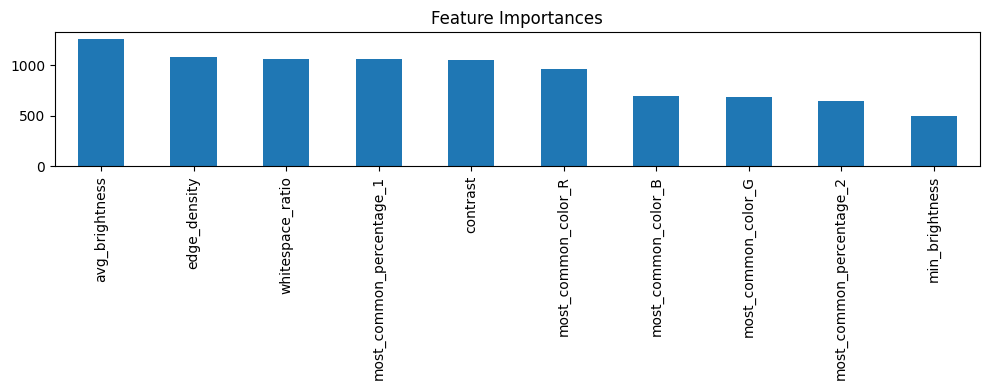

avg_brightness              1263
edge_density                1084
whitespace_ratio            1066
most_common_percentage_1    1059
contrast                    1050
most_common_color_R          959
most_common_color_B          691
most_common_color_G          685
most_common_percentage_2     645
min_brightness               498
dtype: int32


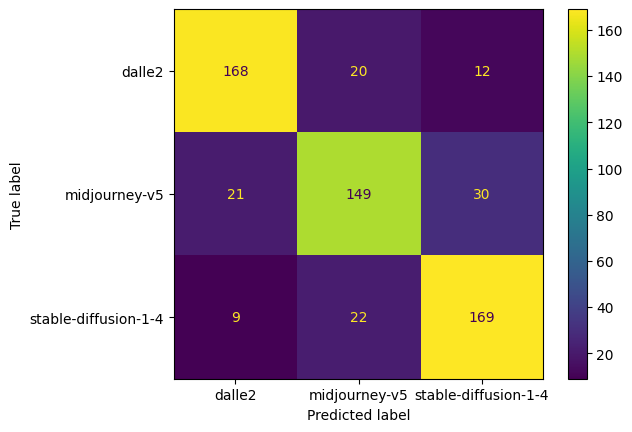

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_selected, y_train)  # ⚠️ No scaling needed
y_pred_lgbm = lgbm_model.predict(X_test_selected)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

import matplotlib.pyplot as plt
import pandas as pd

importances = lgbm_model.feature_importances_
feat_imp = pd.Series(importances, index=selected_features).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10,4), title="Feature Importances")
plt.tight_layout()
plt.show()
print(feat_imp)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lgbm_model, X_test_selected, y_test)



Random Forest Accuracy: 0.79
                      precision    recall  f1-score   support

              dalle2       0.82      0.82      0.82       200
       midjourney-v5       0.76      0.72      0.74       200
stable-diffusion-1-4       0.79      0.82      0.81       200

            accuracy                           0.79       600
           macro avg       0.79      0.79      0.79       600
        weighted avg       0.79      0.79      0.79       600



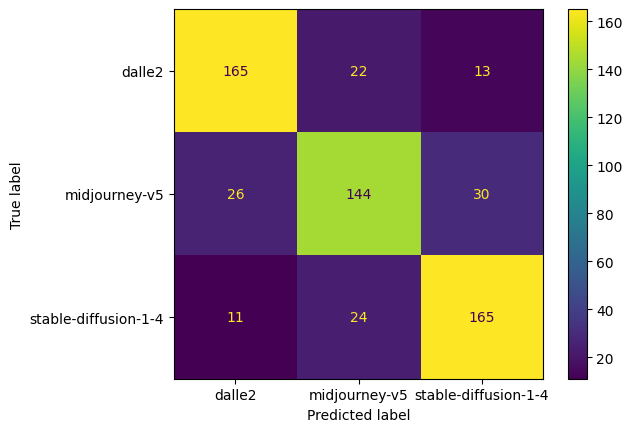

In [ ]:
rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X_train_selected, y_train)
y_pred_rf = rf_final.predict(X_test_selected)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_final, X_test_selected, y_test)
